## Student ID:

## Please do not add further imports. If you think an import is missing, please contact your moderator.

The notebook provides empty cells for your answer to give you guidance on the answer expected from you. You may add cells, but please note this may mean you go beyond what is expected from you and, if this results in unnecessary/unrelated content being added, may reduce your grade.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neural_network import MLPClassifier
from sklearn import svm

from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from skopt.utils import use_named_args

import sys
np.set_printoptions(threshold=sys.maxsize)
import time

# Task 1
## Task 1 Code
The below code is not necessarily complete or applicable to all tasks. Read and understand the code so that you can use wisely and adapt as required.

In [2]:
def plot_margin(X, y, clf):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)


    # plot the decision function
    ax = plt.gca()
    ax.set_aspect(aspect=1)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    # plot support vectors
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')

## Task 1 Instructions 

1. Load dataset Et3_Task1.csv and use a suitable plot to investigate the data.
    - You do not need to look at out-of-sample performance. Hence, there is no '_test' set. Use all available data for training.
2. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a hard margin.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of the support vectors from the trained model.
    - Obtain the performance of your model on training data.
3. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a soft margin with a maximum of 15 support vectors.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of each support vector from the trained model.
    - Obtain the performance of your model on training data.
    - Using information provided by your trained model, identify which of the support vectors lie inside the margin (i.e. are soft margin support vectors).
4. Answer the following questions:
      1. Explain how and why the width of the margin changes as you increase / decrease the C-parameter? Relate this to the Hinge loss error measure (including the regularisation term) used in SVMs. (100 words max)
    2. How and why does the width of the margin affect the expected generalisation abilities of the model? (100 words max)
    3. For the soft-margin model, provide the coordinates of the support vectors that do not violate the margin. (100 words max)

## Task 1 Answer
We suggest to stick to the number of cells provided below.

## 1. Load dataset Et3_Task1.csv and use a suitable plot to investigate the data.
    - You do not need to look at out-of-sample performance. Hence, there is no '_test' set. Use all available data for training.

In [3]:
# load data  csv has 3 columns
data = np.loadtxt('Et3_Task1.csv',dtype='float32',delimiter=',')

X = data[:,0:2]
y = data[:,2]*2 -1

X.shape

(1001, 2)

### 2. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a hard margin.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of the support vectors from the trained model.
    - Obtain the performance of your model on training data.

###################
 Support vectors 
###################
Support Vector [0] -> X1[-1.2471790313720703] X2[-1.5625492334365845] - value y_i * F(x) [0.9994240661132514] is on margin [True]
Support Vector [1] -> X1[0.7803990840911865] X2[1.2246689796447754] - value y_i * F(x) [0.9997110036847141] is on margin [True]
Support Vector [2] -> X1[-1.3800032138824463] X2[-2.742558002471924] - value y_i * F(x) [0.9997151015239376] is on margin [True]

Error :[0.0]
Total Hinge Loss 0.0011498286780968758

#### weights ####

[[ 3.92169214 -2.13560677]]
#### calculate the W with SUM( alpha.y.X_n)
[ 3.92169214 -2.13560677]

#### Margin width ####

0.2239402379039793


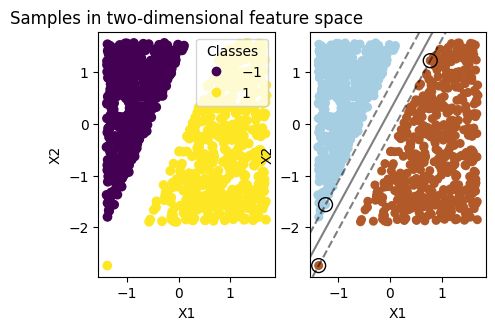

In [25]:
# Plot data
fig,ax = plt.subplots(1,2,figsize=(5,5))
scatter = ax[0].scatter(X[:,0],X[:,1],c=y,label=y)
ax[0].set_xlabel('X1')
ax[0].set_ylabel('X2')
ax[0].legend(*scatter.legend_elements(), loc="upper right", title="Classes")
ax[0].set_title("Samples in two-dimensional feature space")
ax[0].set_aspect(aspect=1)
# add/modify params in the dict
params = {'kernel':'linear','C':10}

cls = svm.SVC(**params)
cls.fit(X,y)

#plt.figure(figsize=(5,5))
ax[1].set_xlabel('X1')
ax[1].set_ylabel('X2')
plot_margin(X,y,cls)

print('###################\n Support vectors \n###################')


delta = 1e-12
# proportional distance from the decision boundary
#val=np.dot(cls.support_vectors_,w.T).reshape(-1)+b
# use the decision_function to calc the dist from the boundary
val = y[cls.support_]*cls.decision_function(cls.support_vectors_)

#on margin    0<alpha <(C- delta)
#inside margin    alpha >= (C-delta)
is_on_margin = (y[cls.support_]*cls.dual_coef_.ravel() <(cls.C-delta)) & (y[cls.support_]*cls.dual_coef_.ravel() >0)

for i,sv in enumerate(cls.support_vectors_):
    print(f'Support Vector [{i}] -> X1[{sv[0]}] X2[{sv[1]}] - value y_i * F(x) [{val[i]}] is on margin [{is_on_margin[i]}]')

###### Error and Cost Function error ######
y_pred = cls.predict(X)
error = np.mean(y_pred!=y)
print(f'\nError :[{error}]')

# verify the hinge loss over all points
# hinge_loss = max(0,y*f(x))
hinge_loss=np.maximum(0,1-y*cls.decision_function(X))
print(f'Total Hinge Loss {np.sum(hinge_loss)}')

print('\n#### weights ####\n')
print(cls.coef_)

# another way to calculate weights SUM(alpha*y*SV) ... leave y out because the dual_coef is already multiplied by the targets
print('#### calculate the W with SUM( alpha.y.X_n)')
print(np.sum((cls.dual_coef_).T*cls.support_vectors_,axis=0))

print('\n#### Margin width ####\n')
print(1/np.linalg.norm(cls.coef_))



### 3. Perform classification on this dataset using an SVM with linear kernel choosing the C parameter to obtain a soft margin with a maximum of 15 support vectors.
    - In a plot containing the data, plot the SVM margins indicating the support vectors.
    - Extract the numerical representation of each support vector from the trained model.
    - Obtain the performance of your model on training data.
    - Using information provided by your trained model, identify which of the support vectors lie inside the margin (i.e. are soft margin support vectors).

###################
 Support vector 
###################
Support Vector [0] -> X1[-0.616031289100647] X2[-0.13954640924930573] - is ON margin [False] value [0.9770426066261642]
Support Vector [1] -> X1[-1.1022367477416992] X2[-1.2138155698776245] - is ON margin [False] value [0.9960414486963185]
Support Vector [2] -> X1[-0.3084060549736023] X2[0.5428694486618042] - is ON margin [False] value [0.968017041639329]
Support Vector [3] -> X1[0.09348243474960327] X2[1.473833680152893] - is ON margin [False] value [0.9996713720712633]
Support Vector [4] -> X1[-0.963208019733429] X2[-0.9325104355812073] - is ON margin [False] value [0.9621029051707599]
Support Vector [5] -> X1[-1.2471790313720703] X2[-1.5625492334365845] - is ON margin [False] value [0.970328794792954]
Support Vector [6] -> X1[0.7803990840911865] X2[1.2246689796447754] - is ON margin [False] value [0.973478283269722]
Support Vector [7] -> X1[-0.16023248434066772] X2[-0.9105014801025391] - is ON margin [True] value [0.9993430282

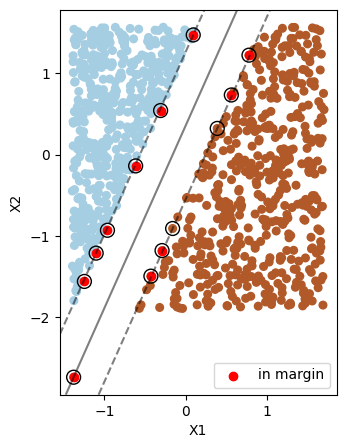

In [28]:
# Plot data
fig,ax = plt.subplots(1,1,figsize=(5,5))


params = {'kernel':'linear','C':0.7}
cls = svm.SVC(**params)
cls.fit(X,y)

#plt.figure(figsize=(5,5))
ax.set_xlabel('X1')
ax.set_ylabel('X2')
plot_margin(X,y,cls)


print('###################\n Support vector \n###################')


# y is [0 1], we need [-1 1]
y_signed = y*2-1
# Get the proportional value for the distance from the decision boundary for each support vector
#val_=(np.dot(cls.support_vectors_,w.T).reshape(-1)+b)
val_=cls.decision_function(cls.support_vectors_)
val=y[cls.support_]*val_

#consider a delta
delta=1e-12


# Use the alphas to verify if SV's are ON/IN margin
#on margin    0<alpha <(C- delta)
#inside margin    alpha >= (C-delta)
is_on_margin = (y_signed[cls.support_]*cls.dual_coef_.ravel() <(cls.C-delta)) & (y_signed[cls.support_]*cls.dual_coef_.ravel() >0)

# plot the sv's in the margin (which are NOT is_on_margin)
ax.scatter(cls.support_vectors_[~is_on_margin,0],cls.support_vectors_[~is_on_margin,1],c='r',label='in margin')
plt.legend()

# indices of cls.support_vectors_ and val are aligned due to the nature of list (ordered)
for i,sv in enumerate(cls.support_vectors_):
    print(f'Support Vector [{i}] -> X1[{sv[0]}] X2[{sv[1]}] - is ON margin [{is_on_margin[i]}] value [{val[i]}]')


# Performance and Error
y_pred = cls.predict(X)
error = np.mean(y_pred!=y)
print(f'\nError :[{error}]')

# Hinge loss max(0,1-yF(x))

hinge_loss=np.maximum(0,1-y_signed*cls.decision_function(X))
print(f'Total Hinge Loss {np.sum(hinge_loss)}')




In [6]:
# ANother way to get the support vectors IN/ON margin is looking at the alphas
# Simply use the alpha
support_idx= cls.support_
support_targets = y[cls.support_]
# according to SVC manual,the alphas are multiplied by the targets => alpha*Y where y [-1,1]. we can revert that by multipying again by the
# their target to get the alphas in the positive range

# support vectors on the margin      0< alpha < C
# support vectors inside the margin     alpha = C
delta=1e-12
alpha_sv=support_targets*cls.dual_coef_.ravel()
sv_on_margin = (alpha_sv>cls.tol) &(alpha_sv<cls.C - delta)
print('#### Support Vectors IN margin')
print(cls.support_vectors_[~sv_on_margin])
print('#### Support Vectors ON margin')
print(cls.support_vectors_[sv_on_margin])
print('\n#### weights ####\n')
print(cls.coef_)
print('\n#### Margin width ####\n')
print(1/np.linalg.norm(cls.coef_))

#### Support Vectors IN margin
[[-0.61603129 -0.13954641]
 [-0.30840605  0.54286945]
 [-0.96320802 -0.93251044]
 [-1.24717903 -1.56254923]
 [ 0.78039908  1.22466898]
 [-1.38000321 -2.742558  ]
 [-0.42786071 -1.49750388]
 [-0.29039815 -1.18210578]
 [ 0.56281561  0.73418081]]
#### Support Vectors ON margin
[[-1.10223675 -1.21381557]
 [ 0.09348243  1.47383368]
 [-0.16023248 -0.91050148]]

#### weights ####

[[ 2.47811601 -1.10247375]]

#### Margin width ####

0.3686923811313319


### 4. Answer the following questions:
    1. Explain how and why the width of the margin changes as you increase / decrease the C-parameter? Relate this to the Hinge loss error measure (including the regularisation term) used in SVMs. (100 words max)
    2. How and why does the width of the margin affect the expected generalisation abilities of the model? (100 words max)
    3. For the soft-margin model, provide the coordinates of the support vectors that do not violate the margin. (100 words max)

## Q1
The objective function used is in the form $C \sum(\mathcal L(f(x_i),y_i)) +\Omega(w)$, where $\mathcal L$ is the hinge loss is given by $\max(0,1-f(x))$.\
As $C$ increases, the hinge loss becomes heavily penalised. The translates less tolerance for having points lying in the margin, which results in narrow margins.\
The margin is $\frac{1}{||w||}$. When there is high penalty given to $\mathcal L$, the optimizer will increase $||w||$ (larger weights) in attempt to reduce the cost function ,resulting in narrow margin.\
As $C$ decreases, the hinge loss becomes less expressive, the optimizer can safely reduce the weights, therefor exibiting a wider margin (small $||w||$). 

The above effect are demonstrated with experiment 2(hard margin) with C=10 (narrow margin) and experiment 3 (soft margin) with C=0.8. \
For the hard margin (C=10), emphasises the penalty $\mathcal L$ (0.0011). The Optimizer has to increase $||w||$ to keep the objective function value to 0 (or near as possible). 
ie. no margin violations.\
With the soft margin, C=0.8, relaxed the penaly on  $\mathcal L$ (1.197), allowing "some" margin violations ,with the effect of reducing $||w||$.\
The weights reduction are observed from 1 experiment to the other:
- [ 3.92169214 -2.13560677] for the C=10 -> narrow margin
- [ 2.47811601 -1.10247375] for the C=0.8 -> wider maring

The core optimization in SVM is to minimize $W_TW$ (same as maximizing $\frac{1}{||w||}$ (margin)). The $\Omega(w)$ term tries to reduce the weight values. In the other hand C plays an opposite role by imposing the penalty on violations, thereby influencing negatively the $\Omega(w)$ term.\
The C factor does have influence on the selected support vectors.

## Q2
The margin is defined as: $\frac{1}{||w||}$. This is the distance between the separating boundary and the line that defines the safety band.\
The goal on tuning the C parameter is to allow more slack for misclassification/margin violation. This parameter will influence the margin width (and the support vectors that define the margin). \
To avoid fitting noise, the model should allow for points within the margin or in the extreme allow misclassification. Larger margins acheive this, they are more resilient to noise. This translates into higer bias, low variance.

Conversly, narrow margins (larger weights), are characterized by "wiggly" shaped curves (for non linear data) in the attempt to minimize violation, making the model more suceptable for noise on training data. This translates into lower bias, higer variance.\
To guarentee generalization, it is favorable to have a model resilient to noise, which is a model that presents a larger margin.


## Q3
the conditions for hard/soft margins are given as:\
$ 0 \gt \alpha \lt C$ - on margin\
$\alpha == C$ - margin violation\
The former condition is satisfied for SV's ON the margin. And they are identified by:\
[-1.10223675 -1.21381557]\
[ 0.09348243  1.47383368]\
[-0.16023248 -0.91050148]


# Task 2
## Task 2 code

In [7]:
def plot_margin(X, y, clf):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, cmap=plt.cm.Paired)


    # plot the decision function
    ax = plt.gca()
    ax.set_aspect(aspect=1)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    # plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    # plot support vectors
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
               linewidth=1, facecolors='none', edgecolors='k')

## Task 2 Instructions 

1. Load dataset Et3_Task2_train and Et3_Task2_test.csv and use a suitable plot to investigate the training data
2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default
3. Visualise the support vectors and margin
4. Train a SVM model and optimise appropriate hyper parameters
5. Visualise the support vectors and margin
6. Explain which model is the best model using the results from step 2-5 to provide as much evidence as possible for your claim (100 words max).

## Task 2 Answer
We suggest to stick to the number of cells provided below.

### 1. Load dataset Et3_Task2_train and Et3_Task2_test.csv and use a suitable plot to investigate the training data.

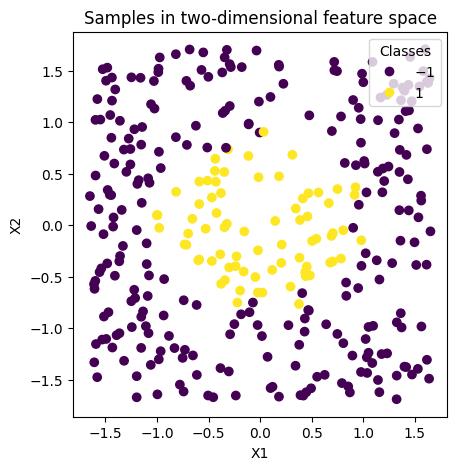

In [8]:
# load data  csv has 3 columns
def load_data(filename):
    data = np.loadtxt(filename,dtype='float',delimiter=',')    
    x = data[:,0:2]
    y = data[:,2]
    return(x,y)
    
X_train,y_train = load_data('Et3_Task2_train.csv')
X_test,y_test = load_data('Et3_Task2_test.csv')

# set Y's from [0 1] to [-1 1]
y_train = y_train*2 -1
y_test = y_test*2 -1

fig,ax = plt.subplots(1,1,figsize=(5,5))
scatter = ax.scatter(X_train[:,0],X_train[:,1],c=y_train,label=y_train)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
ax.set_title("Samples in two-dimensional feature space")
ax.set_aspect(aspect=1)


### 2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default

In [9]:
params = {'kernel':'rbf'}
clf = svm.SVC(**params)
clf.fit(X_train,y_train)


SVC()

### 3. Visualise the support vectors and margin

####  Performance ####
Train accuracy [0.964]
Test accuracy [0.964]
Total Hinge loss [34.152]
####  Support vectors IN and ON margin ####
Total support vectors [(75,)]
Total support vectors on margin (0< alpha < C)[7]
Total support vectors in margin (alpha >= C)[68]


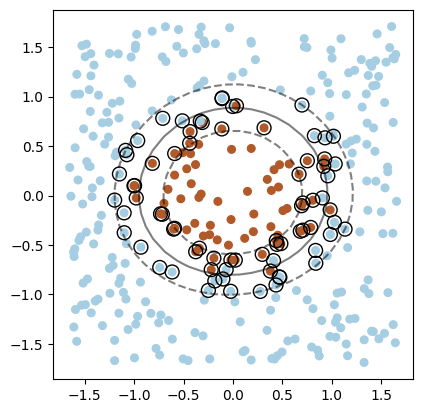

In [ ]:
plot_margin(X_train, y_train, clf)
print('####  Performance ####')
print(f'Train accuracy [{np.round(clf.score(X_train,y_train),3)}]')
print(f'Test accuracy [{np.round(clf.score(X_test,y_test),3)}]')

# Hinge loss max(0,1-yF(x))
# y_signed is in [-1 1]

hinge_loss = np.maximum(0,1-y_train*clf.decision_function(X_train))
print(f'Total Hinge loss [{np.round(np.sum(hinge_loss),3)}]')

delta = 1e-12
print('####  Support vectors IN and ON margin ####')
print(f'Total support vectors [{clf.dual_coef_.ravel().shape}]')
#  0<alpha<C-delta
vectors_on_margin = (np.abs(clf.dual_coef_.ravel())<(clf.C-delta)) & (np.abs(clf.dual_coef_.ravel())>0)
print(f'Total support vectors on margin (0< alpha < C)[{np.sum(vectors_on_margin)}]')
#  alpha>C- delta
vectors_in_margin = (np.abs(clf.dual_coef_.ravel())>(clf.C-delta))
print(f'Total support vectors in margin (alpha >= C)[{np.sum(vectors_in_margin)}]')


### 4. Train a SVM model and optimise appropriate hyper parameters

In [11]:
# quick view of data
print(f'train var {X_train.var()}  train mean { X_train.mean()}')
print(f'test var {X_test.var()}  test mean { X_test.mean()}')
print(f' Class -1 count {np.sum(y_train==-1)}')
print(f' Class 1 count {np.sum(y_train==1)}')

train var 1.0079100942664831  train mean -0.025264855376048664
test var 0.9800129339134487  test mean 0.05129531243015947
 Class -1 count 261
 Class 1 count 74


### 5. Visualise the support vectors and margin

####  Best Parameters ####
{'C': np.float64(69.51927961775606), 'gamma': np.float64(0.14384498882876628)}
####  Performance ####
Cross validation score 0.939
Train accuracy [0.9731]
Test accuracy [0.9758]
Total Hinge loss [19.662]
####  Support vectors IN and ON margin with tolerance 1e-12 ####
Total support vectors [(35,)]
Total support vectors on margin (0< alpha < C)[7]
Total support vectors in margin (alpha >= C)[28]

#####Support vector in Margin and Alphas######

[ True  True  True False  True  True False  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True False  True
  True  True  True False  True  True  True False  True False  True]


array([[-69.51927962, -69.51927962, -69.51927962, -59.82284136,
        -69.51927962, -69.51927962, -30.41191942, -69.51927962,
        -69.51927962, -69.51927962, -69.51927962, -69.51927962,
        -69.51927962, -69.51927962, -69.51927962,  -2.93437448,
        -69.51927962,  69.51927962,  69.51927962,  69.51927962,
         69.51927962,  69.51927962,  46.79137704,  69.51927962,
         69.51927962,  69.51927962,  69.51927962,  26.05147791,
         69.51927962,  69.51927962,  69.51927962,  18.12890369,
         69.51927962,   2.19737661,  69.51927962]])

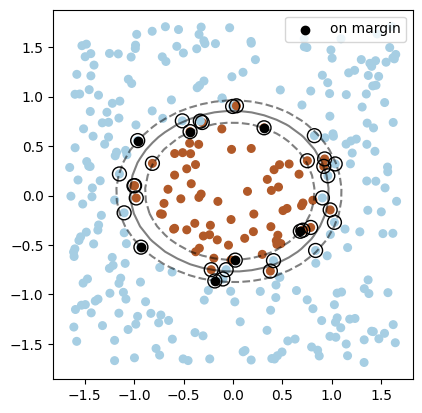

In [12]:

svc = svm.SVC(kernel='rbf')
# grid with 100 combinations
grid_params={
    'gamma':np.logspace(-4,1,20),
    'C':np.logspace(-1,2,20)
}
# use 25% val size
kf = StratifiedKFold(n_splits=4,shuffle=True,random_state=49)
#due to unbalance dont use accuracy. use f1 = TP/(TP+FP)
gs_clf = GridSearchCV(svc,grid_params,cv=kf,scoring='f1',refit=True)
gs_clf.fit(X_train,y_train)


clf = gs_clf.best_estimator_

#plot the SV and boundary margins
plot_margin(X_train, y_train, clf)

print('####  Best Parameters ####')

print(gs_clf.best_params_)


print('####  Performance ####')
print(f'Cross validation score {np.round(gs_clf.best_score_,3)}')
print(f'Train accuracy [{np.round(clf.score(X_train,y_train),4)}]')
print(f'Test accuracy [{np.round(clf.score(X_test,y_test),4)}]')

# hinge loss max(0,1-y_i*F(x))
# y_signed is in [-1 1]
hinge_loss = np.maximum(0,1-y_train*clf.decision_function(X_train))
print(f'Total Hinge loss [{np.round(np.sum(hinge_loss),3)}]')

delta=1e-12
print(f'####  Support vectors IN and ON margin with tolerance {delta} ####')
print(f'Total support vectors [{clf.dual_coef_.ravel().shape}]')
#  tol<alpha<C-tol
vectors_on_margin = (np.abs(clf.dual_coef_.ravel())<(clf.C-delta)) &(np.abs(clf.dual_coef_.ravel())>delta)
print(f'Total support vectors on margin (0< alpha < C)[{np.sum(vectors_on_margin)}]')
#  alpha>C-tol
vectors_in_margin = (np.abs(clf.dual_coef_.ravel())>=(clf.C-delta))
print(f'Total support vectors in margin (alpha >= C)[{np.sum(vectors_in_margin)}]')

print('\n#####Support vector in Margin and Alphas######\n')
# support vectors in the margin
in_margin_idx=(np.abs(clf.dual_coef_)>=clf.C).ravel()
print(in_margin_idx)

ax = plt.gca()
ax.scatter(clf.support_vectors_[~in_margin_idx,0],clf.support_vectors_[~in_margin_idx,1],c='k',label='on margin')
plt.legend()

clf.dual_coef_

############################


### 6. Explain which model is the best model using the results from step 2-5 to provide as much evidence as possible for your claim (100 words max).

Since we are using the Radial kernel, we are not able to judge numerically the width of the margin in the $\mathcal Z$ space (since the coef are only available for linear kernels).$\mathcal Z$ space is also an infinit dimentional space.
The selection model would be based on the #Support Vectors, cross validation results and the performance metrics.
From the bound $E[E_{out}] \lt \frac{E[\#SV]}{N-1}$, less Support vectors would provide a better bound.

Results:
- Tunned model\
E_test = 97.5\
\#Support vectors=35

- non tunned model\
E_test = 96.4\
\#Support vectors=75


The tunned model seems to be best suited for this case, as it presents less SV's and 1% better accuracy.
According to the $E_{out}$ bound, $\frac{35}{334} \approx 10.4\%$

# Task 3
## Task 3 code
This wrapper is required in below BayesSearchCV for a neural network to combine the two layer arguments (or more if you wish to experiment with more than two layers) into the single hidden_layer_sizes hyper-parameter.

In [13]:
class MLPWrapper(BaseEstimator, ClassifierMixin):
    
    def __init__(self, 
                 layer1=100, 
                 layer2=100, 
                 alpha=0.0001, 
                 activation='relu', 
                 learning_rate_init=1e-3,
                 early_stopping = False,
                 n_iter_no_change = 10,
                solver = 'adam'):
        self.layer1 = layer1
        self.layer2 = layer2
        self.alpha = alpha
        self.activation = activation
        self.learning_rate_init = learning_rate_init
        self.early_stopping = early_stopping
        self.n_iter_no_change = n_iter_no_change
        self.solver = solver

    def fit(self, X, y):
        model = MLPClassifier(
            hidden_layer_sizes=[self.layer1, self.layer2],
            alpha=self.alpha,
            max_iter = 1000,
            activation = self.activation,
            learning_rate_init = self.learning_rate_init,
            early_stopping = self.early_stopping,
            n_iter_no_change = self.n_iter_no_change,
            solver = self.solver,
            random_state=10
        )
        model.fit(X, y)
        self.model = model
        return self

    def predict(self, X):
        return self.model.predict(X)

    def score(self, X, y):
        return self.model.score(X, y)
    
    def get_model():
        return self.model

In [14]:
# Example use of BayesSearchCV to search a large search space whilst keeping compute requirements in check

optSVM1_lin = BayesSearchCV(
    svm.SVC(),
    {
      'C': Real(1e-3, 1e+3, prior='log-uniform'),
        'kernel': Categorical(['linear']),
    },
    n_iter=40,
)

In [15]:
# Example use of BayesSearchCV with the MLPWrapper to vary the layer sizes

optNN1 = BayesSearchCV(
    estimator=MLPWrapper(),
    search_spaces={
        'layer1': Integer(1, 100),
        'layer2': Integer(1, 100)
    },
    n_iter=40,
)

## Task 3 Instructions
1. Load dataset Et3_Task3_train and Et3_Task3_test.csv.
2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data
3. Train a SVM model and optimise appropriate hyper parameters
    - Try 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relatively small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data
    - Try to achieve a score of > 0.85 on test data for at least one of the searches
4. Train a neural network with a suitable activation function and guestimates for the hidden layer sizes but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data
5. Train a neural network and optimise appropriate hyper parameters
    - Use 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relative small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data
    - Try to achieve a score of > 0.84 on test data for at least one of the searches
6. Answer the following questions:
   1. Explain the difference in performance between the two search strategies for each of the models (SVM and Neural Network). Point out any deviations (if any) from what you expected and potential fixes. If you ended up not using one of the search strategies for either step 3 or step 5, explain why (200 words max).
   2. Explain the major considerations when choosing between Bayesian and grid-based hyper-parameter optimisation (100 words max).
   2. When choosing the kernel type is part of SVM optimisation, what is key in reducing compute time as much as possible (100 words max)?  
    

## Task 3 Answer
We suggest to stick to the number of cells provided below.

### 1. Load dataset Et3_Task3_train and Et3_Task3_test.csv and use a suitable plot to investigate the training data.

In [16]:
# load data  csv has 3 columns
def load_data(filename):
    data = np.loadtxt(filename,dtype='float',delimiter=',')    
    x = data[:,0:20]
    y = data[:,20]
    return x,y
    

#data_train= load_data('Et3_Task3_train.csv')
#data_train.shape
X_train,y_train = load_data('Et3_Task3_train.csv')
X_test,y_test = load_data('Et3_Task3_test.csv')

print(f'Train shape {X_train.shape}')
print(f'Test shape {X_test.shape}')
# quick view of data
print(f'train var {X_train.var()}  train mean { X_train.mean()}')
print(f'test var {X_test.var()}  test mean { X_test.mean()}')
print(f' Class 0 count {np.sum(y_train==0)}')
print(f' Class 1 count {np.sum(y_train==1)}')

Train shape (1750, 20)
Test shape (750, 20)
train var 1.0  train mean -2.5579538487363606e-17
test var 1.0249647082691093  test mean 0.012696301097416445
 Class 0 count 875
 Class 1 count 875


### 2. Train a SVM model with a suitable kernel but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data

In [17]:
svc = svm.SVC()

rbf_space={
    'kernel':['rbf'],
    #'gamma':['scale',0.0001,0.001,0.01,0.1,1],
    #'C':np.logspace(-3,2,50)
}

kf = StratifiedKFold(n_splits=10,shuffle=True,random_state=49)
gs_clf = GridSearchCV(svc,[rbf_space],cv=kf,n_jobs=6)
gs_clf.fit(X_train,y_train)


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=49, shuffle=True),
             estimator=SVC(), n_jobs=6, param_grid=[{'kernel': ['rbf']}])

In [18]:
print(f'Train accuracy {gs_clf.best_estimator_.score(X_train,y_train)}')
print(f'Test accuracy {gs_clf.best_estimator_.score(X_test,y_test)}')
print (f'alpha vector shape [{gs_clf.best_estimator_.dual_coef_.shape}]')

Train accuracy 0.9085714285714286
Test accuracy 0.8453333333333334
alpha vector shape [(1, 920)]


### 3. Train a SVM model and optimise appropriate hyper parameters
    - Use 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relative small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data

In [19]:
gamma_scale = 1/(X_train.shape[0]*np.var(X_train))
gamma_scale

#  The feats are scaled with var=1 and mean=0... so they are good to go for RBF
#np.var(X_train)
#np.mean(X_train)
# data is balanced
#np.sum(y_train>0)

np.float64(0.0005714285714285715)

In [ ]:
#Search 1:
start_time = time.time()
svc = svm.SVC()

poly_space={
    'kernel': ['poly'],
    'degree': np.arange(3,10,2),
    'C': np.logspace(-3,2,10),
}

rbf_space={
    'kernel': ['rbf'],
    'gamma': np.logspace(-5,-1,20),
    'C': np.logspace(-1,2,20)
}

# keep fold with 20% of data, so that validation is more reliable
kf = StratifiedKFold(n_splits=5,shuffle=True,random_state=101)
# classes are balanced, so we can use accuracy
gs_clf = GridSearchCV(svc,[rbf_space,poly_space],cv=kf,n_jobs=6,refit=True,scoring='accuracy',return_train_score=True,
                      error_score='raise',verbose=1)
gs_clf.fit(X_train,y_train)

end_time = time.time()
print(gs_clf.best_params_)
print("---Execution Time: %s seconds ---" % (time.time() - start_time))
print(" best score %f" % (gs_clf.best_score_))
print(" Train Accuracy %f" % (gs_clf.best_estimator_.score(X_train,y_train)))
print(" Test Accuracy %f" % (gs_clf.best_estimator_.score(X_test,y_test)))
print('\n####   Alpha vector shape ###')
gs_clf.best_estimator_.dual_coef_.shape

Fitting 5 folds for each of 460 candidates, totalling 2300 fits


{'C': np.float64(3.79269019073225), 'gamma': np.float64(0.005455594781168515), 'kernel': 'rbf'}
---Execution Time: 132.86611032485962 seconds ---
 best score 0.850857
 Train Accuracy 0.860571
 Test Accuracy 0.850667

####   Alpha vector shape ###


(1, 738)

In [21]:
#Search 2

start_time = time.time()

linear_space={
    'kernel':Categorical(['linear']),
    'C': Real(1e-2, 1e+2, prior='log-uniform'),
}

poly_space={
    'kernel':Categorical(['poly']),
    'degree': Integer(3,10),
    'C': Real(1e-3, 1e+2, prior='log-uniform'),
}

rbf_space={
    'kernel':Categorical(['rbf']),
    'gamma': Real(1e-5, 1e-1, prior='log-uniform'),
    'C': Real(1e-1, 1e+2, prior='log-uniform'),
}

sigmoid_space={
    'kernel':Categorical(['sigmoid']),
    'gamma':Real(1e-5, 1e-1, prior='log-uniform'),
    'C': Real(1e-1, 1e+1, prior='log-uniform'),
}



kf = StratifiedKFold(n_splits=5,shuffle=True,random_state=49)
bs_clf = BayesSearchCV(
    svm.SVC(kernel='rbf'),
    [(rbf_space,60),(linear_space,10),(poly_space,20)],
    n_points=3,
    n_jobs=6,
    cv=kf,
    random_state=49,
    scoring='accuracy',
    verbose=1
)

bs_clf.fit(X_train,y_train)


print("---Execution Time: %s seconds ---" % (time.time() - start_time))
print("val. score: %s" % bs_clf.best_score_)
print("test score: %s" % bs_clf.score(X_test, y_test))
print("best params: %s" % str(bs_clf.best_params_))
bs_clf.best_estimator_.dual_coef_.shape


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Fitting 5 folds for each of 3 candidates

(1, 776)

### 4. Train a neural network with a suitable activation function and guestimates for the hidden layer sizes but otherwise all hyper parameters as default
    - Print the performance on training data
    - Print the performance on test data

In [22]:
mpl_clf = MLPWrapper(layer1=6,layer2=3,activation='relu')
mpl_clf.fit(X_train,y_train)

print(mpl_clf.score(X_train,y_train))
print(mpl_clf.score(X_test,y_test))

0.8645714285714285
0.8413333333333334


### 5. Train a neural network and optimise appropriate hyper parameters
    - Use 2 searches: try both Grid-based searches and Bayesian searches. Note that these can take considerable time so set them up correctly first with a small number of feature dimensions / iterations to check correctness. Then increase the number of features dimensions / iterations and wait. You may wish to get a sense of train times with a relative small number of iterations first.  
    - Keep track of the time required for the full search
    - Print the performance on training data
    - Print the performance on test data

In [23]:
#Search 1

mpl_param_search ={
    'layer1':[8,9,10],
    'layer2':[4,5,6],
    'alpha':np.logspace(-5,0,6),
    'activation':['relu','logistic'],
    'learning_rate_init':np.logspace(-5,-2,4)
}

kf = StratifiedKFold(n_splits=5,shuffle=True,random_state=49)
gs_mpl = GridSearchCV(MLPWrapper(),mpl_param_search,cv=kf,n_jobs=6,scoring='accuracy',refit=True,return_train_score=True)

start_time = time.time()
gs_mpl.fit(X_train,y_train)

end_time = time.time()

print("--- %s seconds ---" % (time.time() - start_time))
print("val. score: %s" % gs_mpl.best_score_)
print("test score: %s" % gs_mpl.score(X_test, y_test))
print("best params: %s" % str(gs_mpl.best_params_))

--- 827.3585290908813 seconds ---
val. score: 0.8502857142857143
test score: 0.848
best params: {'activation': 'logistic', 'alpha': np.float64(1.0), 'layer1': 10, 'layer2': 4, 'learning_rate_init': np.float64(0.01)}


In [24]:
#Search 2
mpl_param_search ={
    'layer1':Integer(6,11),
    'layer2':Integer(2,6),
    
    'alpha':Real(1e-5, 1e1, prior='log-uniform'),
    'activation':Categorical(['relu','logistic']),
    'learning_rate_init':Real(1e-5, 1e-2, prior='log-uniform'),
}

kf = StratifiedKFold(n_splits=5,shuffle=True,random_state=49)
bs_clf = BayesSearchCV(
    MLPWrapper(),
    mpl_param_search,
    n_jobs=6,
    n_points=4,
    cv=kf,
    scoring='accuracy',
    n_iter=60,
    refit=True
)

start_time = time.time()
bs_clf.fit(X_train,y_train)

end_time = time.time()

print("--- %s seconds ---" % (time.time() - start_time))
print("val. score: %s" % bs_clf.best_score_)
print("test score: %s" % bs_clf.score(X_test, y_test))
print("best params: %s" % str(bs_clf.best_params_))


--- 262.5969853401184 seconds ---
val. score: 0.8497142857142856
test score: 0.8466666666666667
best params: OrderedDict([('activation', 'relu'), ('alpha', 10.0), ('layer1', 9), ('layer2', 2), ('learning_rate_init', 0.005285188561101478)])


6. Answer the following questions:
   1. Explain the difference in performance between the two search strategies for each of the models (SVM and Neural Network). Point out any deviations (if any) from what you expected and potential fixes. If you ended up not using one of the search strategies for either step 3 or step 5, explain why (200 words max).
   2. Explain the major considerations when choosing between Bayesian and grid-based hyper-parameter optimisation (100 words max).
   2. When choosing the kernel type is part of SVM optimisation, what is key in reducing compute time as much as possible (100 words max)?  

## Q1
Assuming the performance of GridSearch/Bayesian for SVM and NN\
### SVM:
Exeution performance favours Bayesian search due to its sampling efficiency. It selects the next set of parameters based on its prior knowledge. Each iteration tends to get closer to the "optimum" spot. In contrast, Gridsearch does an exaustive search on all parameter combinations.
There are deviations between the GridSearchCv and BayesianCv, and somehow they are expected as the 2 main parameters $C$ and $\gamma$ interact strongly. C is the SVM regularizer for the loss function, and $\gamma$ indirectly regularizes the kernel. In the RBF case, lower $\gamma$ translates to a smooth gaussean curve, which smoothens the similarity function (making 2 points away are more similar).\
The stochasic nature of BayesianSeach will explore different regions then GridSearch, and as result different value for $C$ and $\gamma$. Due to the strong interaction between $C$ and $\gamma$, any nudge in C will require a modification on $\gamma$, which might result in different magnitudes.

### NN
Some deviations are also noticed between GridSearch and Bayesian.
While Gridseach provided more neurons (10,4) and higer $\mu$ (0.01) $\alpha$ (1), BaysianSearch returned less neurons (7,4) lower $\alpha$ (0.85) and lower $\mu$ (0.0007).\
When there are more parameters in the model (higer VC, total 240 only for hidden layer), there is a need for stronger regularization to avoid overfitting - results from GridSearch

Conversely, less parameters (lower VC,total 161 only for hidden layer), requires weaker regularization - results from Bayesian.
Its concluded that there is a correlation between #neuros_per_layer and the the regularization.



## Q2
GridSearch does an exaustive search using all combination of parameters.This type of search is based on exploration.\
When using a considerable hyperparameters selection, this will be costly, and time consuming. Another consideration is that it uses the given values for the search. 
Bayesian search balances exploration and exploitation,where it  will create a surrogate model of the objective. Based on initial explorations, it will exploit regions with higer probability of success (higer accuracy). This is ideal when the hyperparameter seach space is considerable large. Usualy this results in less fits (adjusting the n_iter and n_points)
When to use which?
- GridSearch:\
  when models are simple (not often)\
  collect a coarse region of parameters values (use small spaces)\
  when #parameters are reduced 3-4\
- Bayesian:\
  Models expensive to train - hyperOpt is another alternative!
  search space is considerable large


  
## Q3
Finding the most promissing Kernel is an iterative process. Using prior knwoledge can be be an advantage. If data is not linearly separable, then linear kernel is not an option.
Start to create individual spaces for each kernels with  narrow search spaces for each kernel (coarse search), and make use of logarithmically spaced values for sensitive parameters like $C$,$\gamma$.
Based on the CrossValidation result, then focus on the most promissing kernel and refine the search space based around the values obtained by the "coarse" search.


# Reflection

Clearly describe the changes you have made based on your peers' work and feedback (100 words max).
Describe your understanding of:
1. How hyper-parameters effect complexity and what our goal is in tuning hyper parameters (100 words max).
2. What aspects of your machine learning model determine whether a grid search or a Bayesian search is most appropriate, and why (150 words max).